In [1]:
import ComicGTN
import os
import re
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from ComicGTN.utils import *
from ComicGTN.settings import *
from ComicGTN.GCNConv import *
from ComicGTN.FastGTNConv import *
from ComicGTN.ComicGTN_model import *


workdir = "./ComicGTN_reproducibility/Data/Mouse_breast_tumor"
RNA_seq = sc.read(os.path.join(workdir, "Gene_Cell.mtx"))
ATAC_seq = sc.read(os.path.join(workdir, "Peak_Cell.mtx"))
Cell_names = pd.read_csv(os.path.join(workdir, "Cell_names.tsv"), sep = "\t", header = None)
Cell_types = pd.read_csv(os.path.join(workdir, "Cell_types.tsv"), sep = "\t", header = None)
Gene_names = pd.read_csv(os.path.join(workdir, "Gene_names.tsv"), sep = "\t", header = None)
Peak_names = pd.read_csv(os.path.join(workdir, "Peak_names.tsv"), sep = "\t", header = None)
RNA_seq.obs_names = Gene_names[0]
RNA_seq.var_names = Cell_names[0].astype(str)
ATAC_seq.obs_names = Peak_names[0]
ATAC_seq.var_names = Cell_names[0].astype(str)
RNA_count = RNA_seq.X
ATAC_count = ATAC_seq.X


Kmer_adata = ad.io.read_hdf(os.path.join(workdir, "output_kmers_motifs/freq_kmer.h5"), "mat")        
Motif_adata = ad.io.read_hdf(os.path.join(workdir, "output_kmers_motifs/freq_motif.h5"), "mat")      
Kmer_adata.obs_names = Peak_names.iloc[0:len(Kmer_adata.obs.index), 0]
Kmer_adata.var_names = [x.decode("utf-8") for x in Kmer_adata.var.index]
Motif_adata.obs_names = Peak_names.iloc[0:len(Motif_adata.obs.index), 0]
Motif_adata.var_names = [x.decode("utf-8") for x in Motif_adata.var.index]
Kmer_count = Kmer_adata.X 
Motif_count = Motif_adata.X

ATAC_count_re, Peak_names_re = Remove_Scaffold(ATAC_count, Peak_names)

In [2]:
import argparse


parser = argparse.ArgumentParser(description = "Training GTN on heterogeneous graph.")
parser.add_argument("--num_FastGTN_layers", type = int, default = 1)
parser.add_argument("--num_channels", type = int, default = 8)
parser.add_argument("--num_layers", type = int, default = 4)
parser.add_argument("--node_dim", type = int, default = 128)
parser.add_argument("--non_local", type = bool, default = False)
parser.add_argument("--non_local_weight", type = int, default = 0)
parser.add_argument("--K", type = int, default = 1)
parser.add_argument("--beta", type = float, default = 0)
parser.add_argument("--channel_agg", type = str, default = "mean")
parser.add_argument("--remove_self_loops", type = bool, default = True)
parser.add_argument("--smoothing", type = float, default = 0.1)
parser.add_argument("--rare_weight", type = list, default = [2.0, 3.0])
parser.add_argument("--temperature", type = float, default = 0.1)
parser.add_argument("--hard_neg_k", type = int, default = 3)
parser.add_argument("--rand_neg_ratio", type = float, default = 0.3)
parser.add_argument("--lr", type = float, default = 0.0005)
parser.add_argument("--weight_decay", type = float, default = 0.005)


args = parser.parse_args([])
num_FastGTN_layers = args.num_FastGTN_layers
num_channels = args.num_channels
num_layers = args.num_layers
node_dim = args.node_dim
non_local = args.non_local
non_local_weight = args.non_local_weight
K = args.K
beta = args.beta
channel_agg = args.channel_agg
remove_self_loops = args.remove_self_loops
smoothing = args.smoothing
rare_weight = args.rare_weight
temperature = args.temperature
hard_neg_k = args.hard_neg_k
rand_neg_ratio = args.rand_neg_ratio
lr = args.lr
weight_decay = args.weight_decay

In [3]:
if __name__ == "__main__":
    device = f"cuda" if torch.cuda.is_available() else "cpu"
    print("You will use : ",device)
    
    
    initial_pre = Initial_Clustering(RNA_count) 
    cluster_ini_num = len(set(initial_pre)) 
    ini_clu = [int(i) for i in initial_pre]
    total_node_idx, cell_node_idx, dic_cell, dic_peak = Subgraph_Extraction(RNA_count, ATAC_count_re, Kmer_count, 
                                                                                                                       Motif_count, neighbor_node_num = [20, 20, 5, 2], 
                                                                                                                       cell_node_num = 30)
    
    rare_labels = Calculate_Frequency(ini_clu)
    num_edge_type = 5
    node_model = NodeFeatureEmbedding(RNA_count, ATAC_count, Kmer_count, Motif_count, total_node_idx, ini_clu,
                                                                      rare_labels, args, device, num_edge_type, epochs = 1)
    GTN, cell_emb, gene_emb, peak_emb, kmer_emb, motif_emb = node_model.train_process(batch_num = len(total_node_idx))
    
    
    Comic_model = Comic(GTN = GTN,  batch_num = len(total_node_idx), rare_labels = rare_labels, 
                                          args = args, device = device, epochs = 1)
    ComicGTN = Comic_model.train_process(total_node_idx, RNA_count, ATAC_count, Kmer_count, Motif_count, ini_clu)
    
    
    cell_node_num = 30
    Comic_result = ComicGTN_test(RNA_count, ATAC_count, Kmer_count, Motif_count, total_node_idx, cell_node_idx, 
                                                       cell_node_num, ComicGTN, device, co_emb = True)
    
    
outputdir = "./ComicGTN_reproducibility/Data/Mouse_breast_tumor"

pred_labels = Comic_result["predicted_cluster_label"]
sorted_cell_node_idx, sorted_custom_labels = zip(*sorted(zip(cell_node_idx, pred_labels)))
sorted_custom_labels = pd.DataFrame(list(sorted_custom_labels))
sorted_custom_labels.to_csv(os.path.join(outputdir, "ComicGTN_pred.tsv"), sep = "\t", header = False, index = False)

/home/jsl/anaconda3/envs/python3.10/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/jsl/anaconda3/envs/python3.10/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 24281 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

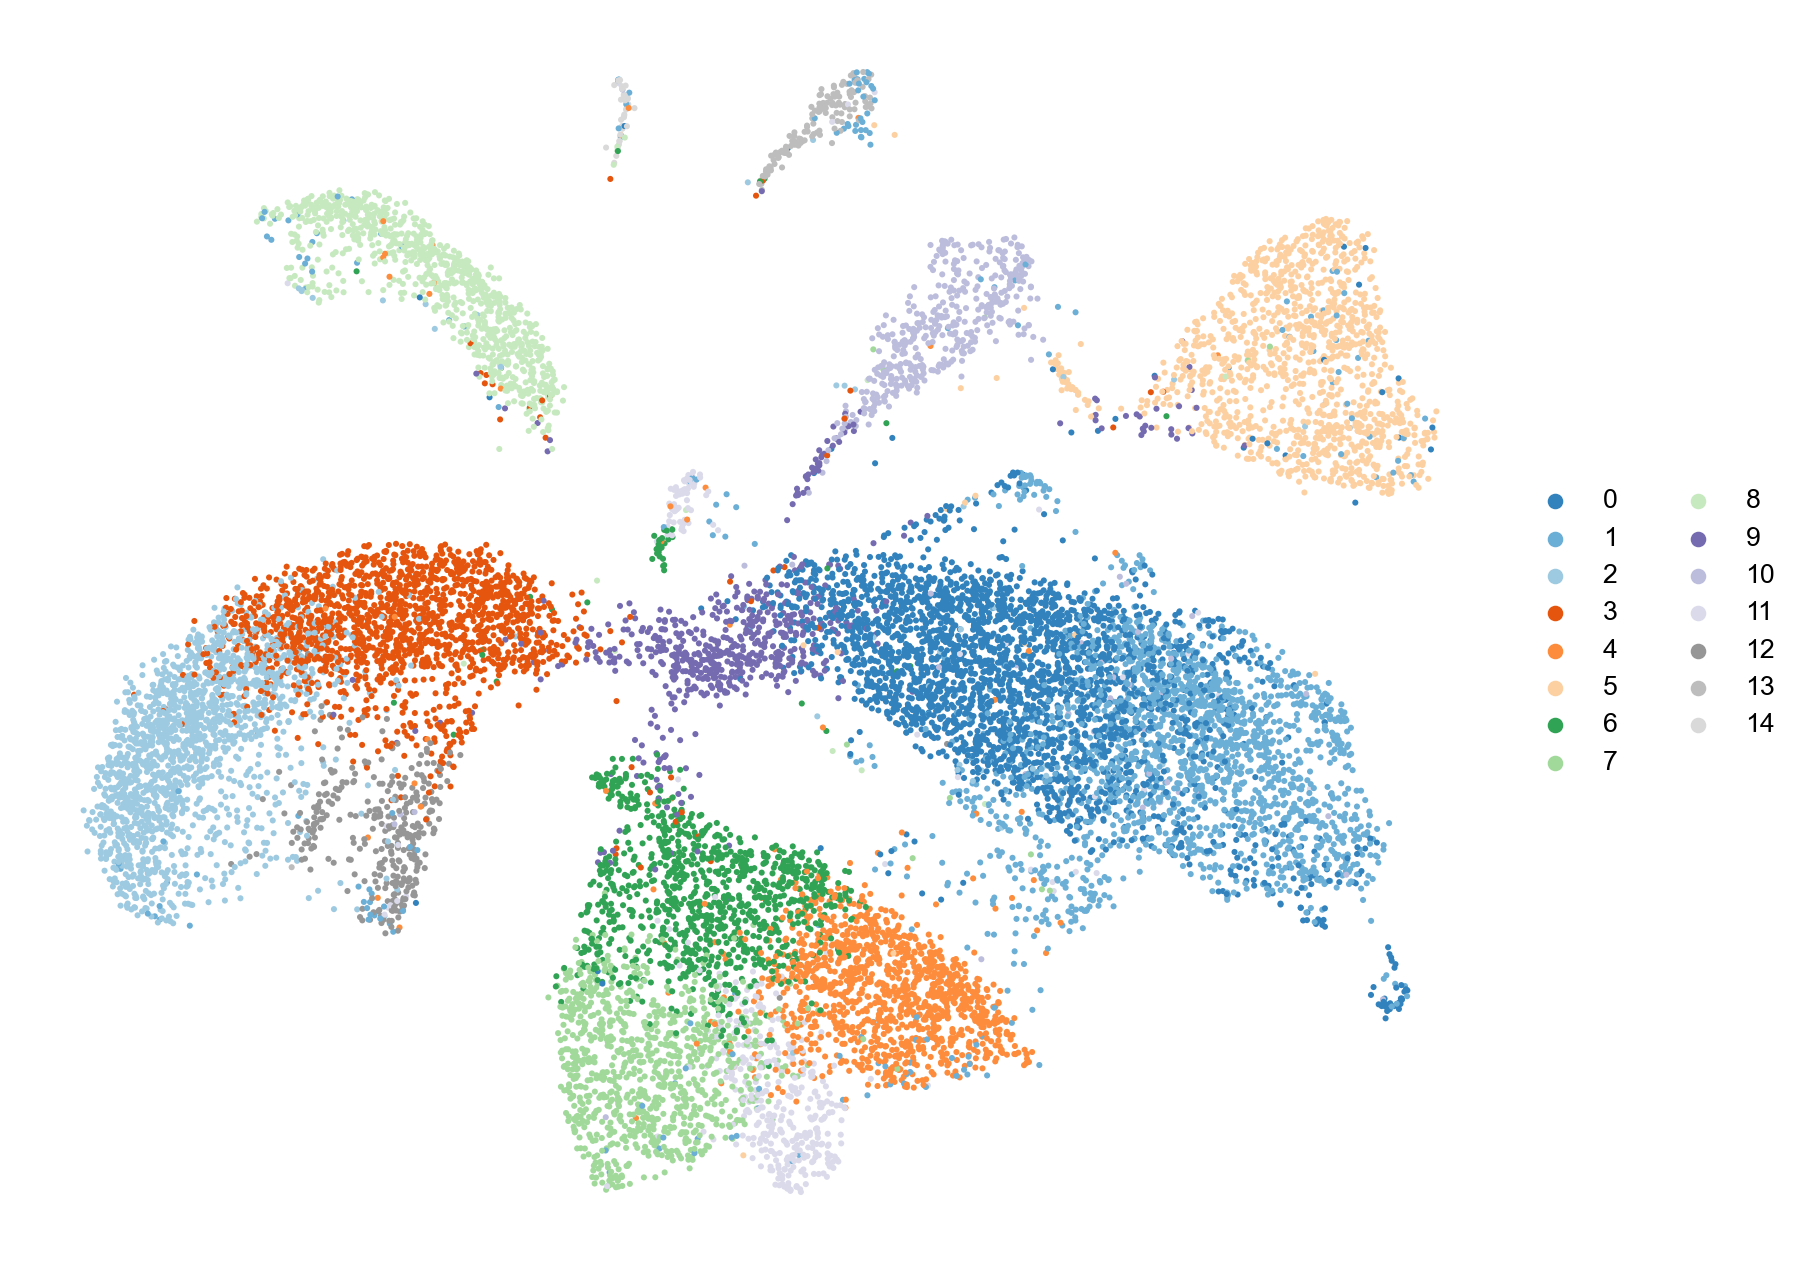

In [20]:
import matplotlib.pyplot as plt


plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12
RNA_seq = sc.read(os.path.join(workdir, "Gene_Cell.mtx"))
Cell_names = pd.read_csv(os.path.join(workdir, "Cell_names.tsv"), sep = "\t", header = None)
Gene_names = pd.read_csv(os.path.join(workdir, "Gene_names.tsv"), sep = "\t", header = None)
pred_labels = pd.read_csv(os.path.join(workdir, "ComicGTN_pred.tsv"), sep = "\t", header = None)
RNA_count = RNA_seq.X
adata =  ad.AnnData(RNA_count.transpose(), dtype = "int32")
adata.obs_names = Cell_names[0]
adata.var_names = Gene_names[0]
adata.var_names_make_unique()
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.scale(adata, max_value = 10)
adata.obs["labels"] = pred_labels[0].tolist()
adata.obs["labels"] = adata.obs["labels"].astype("category")
sc.pp.neighbors(adata, 15)
sc.tl.umap(adata)
fig, ax = plt.subplots(figsize = (12, 10))
sc.pl.umap(adata, size = 30, color = ["labels"], palette = "tab20c", title = "", frameon = False, ax = ax, show = False)

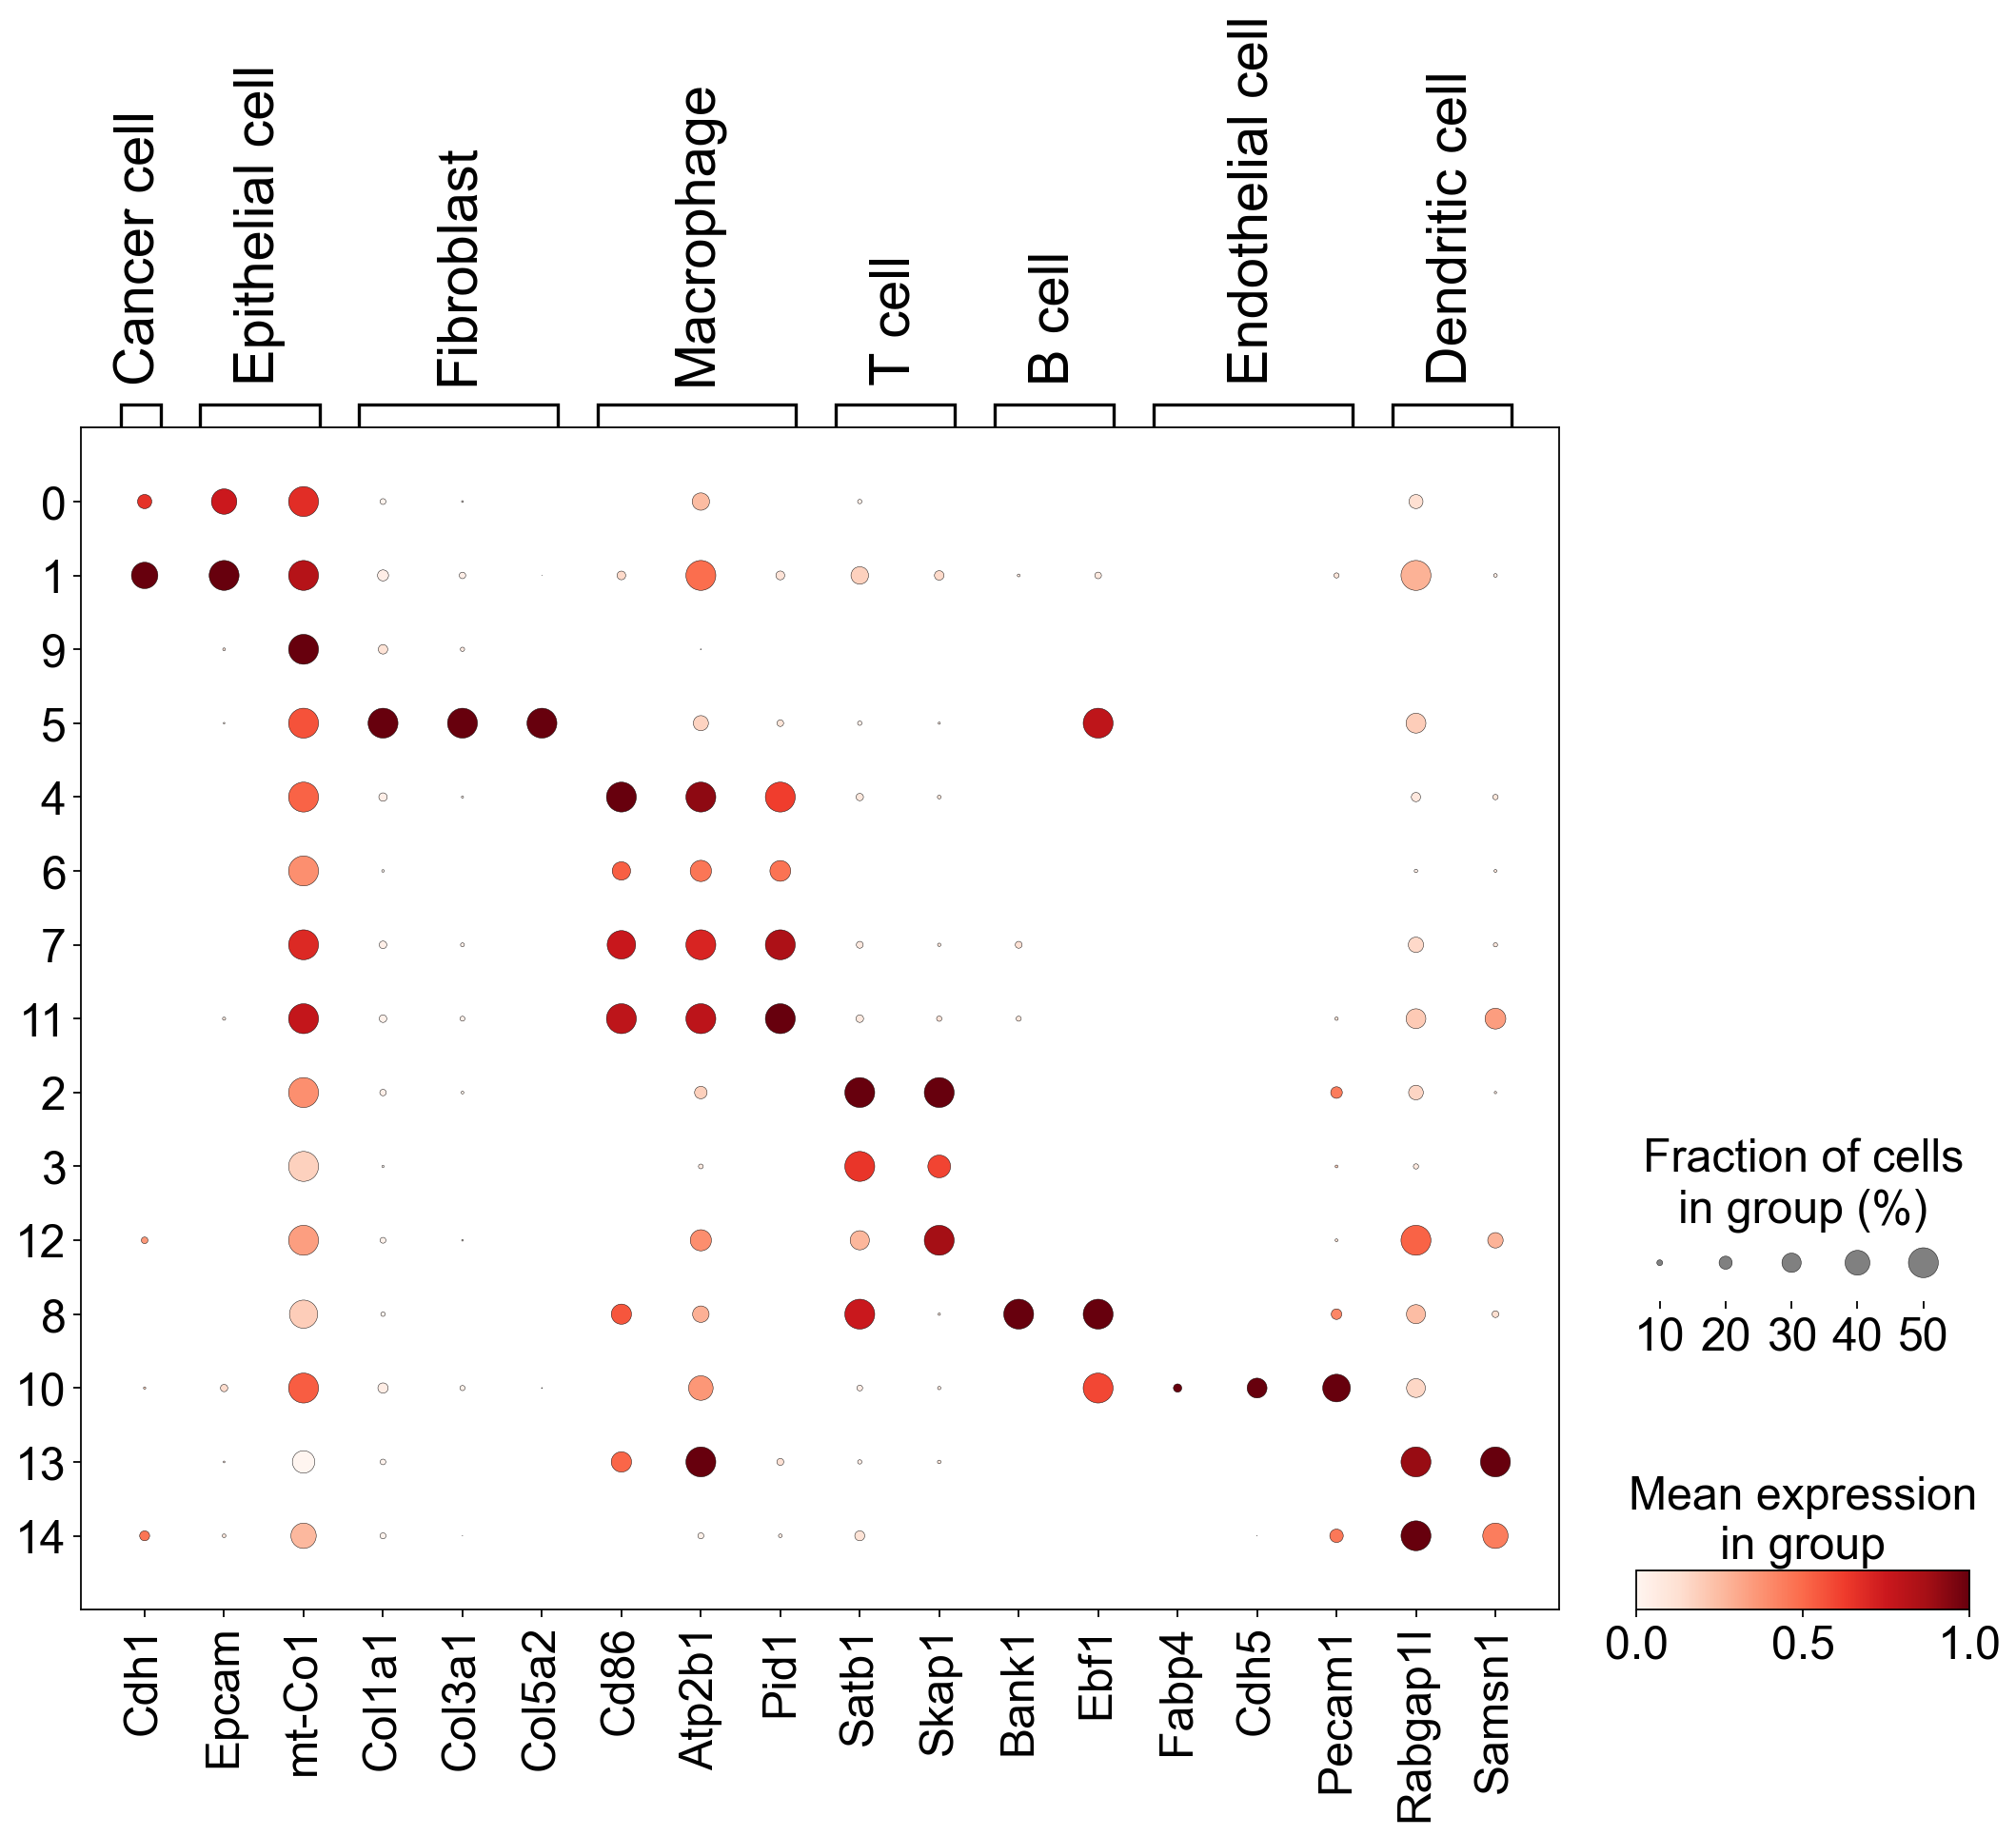

In [12]:
sc.set_figure_params(scanpy = False)


pred_labels = pd.read_csv(os.path.join(workdir, "ComicGTN_pred.tsv"), sep = "\t", header = None)
labels = pred_labels[0].tolist()
adata.obs["labels"] = labels
adata.obs["labels"] = adata.obs["labels"].astype("str")
plt.rcParams["font.size"] = 26
marker_genes = {"Cancer cell": ["Cdh1"],
                            "Epithelial cell": ["Epcam", "mt-Co1"],
                            "Fibroblast": ["Col1a1", "Col3a1", "Col5a2"],
                            "Macrophage": ["Cd86", "Atp2b1", "Pid1"],
                            "T cell": ["Satb1", "Skap1"],
                            "B cell": ["Bank1", "Ebf1"],
                            "Endothelial cell": ["Fabp4", "Cdh5", "Pecam1"],
                            "Dendritic cell": ["Rabgap1l", "Samsn1"]}
marker_genes_dict = dict()


for ct, markers in marker_genes.items():
    markers_found = list()
    
    for marker in markers:
        if marker in adata.var_names:
            markers_found.append(marker)
    marker_genes_dict[ct] = markers_found
    
del_markers = list()

for ct, markers in marker_genes_dict.items():
    if markers == []:
        del_markers.append(ct)
        
for ct in del_markers:
    del marker_genes_dict[ct]


order = ["0", "1", "9", "5", "4", "6", "7", "11", "2", "3", "12", "8", "10", "13", "14"]
fig, ax = plt.subplots(figsize = (16, 12))
sc.pl.dotplot(adata, groupby = "labels", var_names = marker_genes_dict, dot_max = 0.5, dot_min = 0.05, 
                     standard_scale = "var", categories_order = order, ax = ax, show = False)
plt.show()

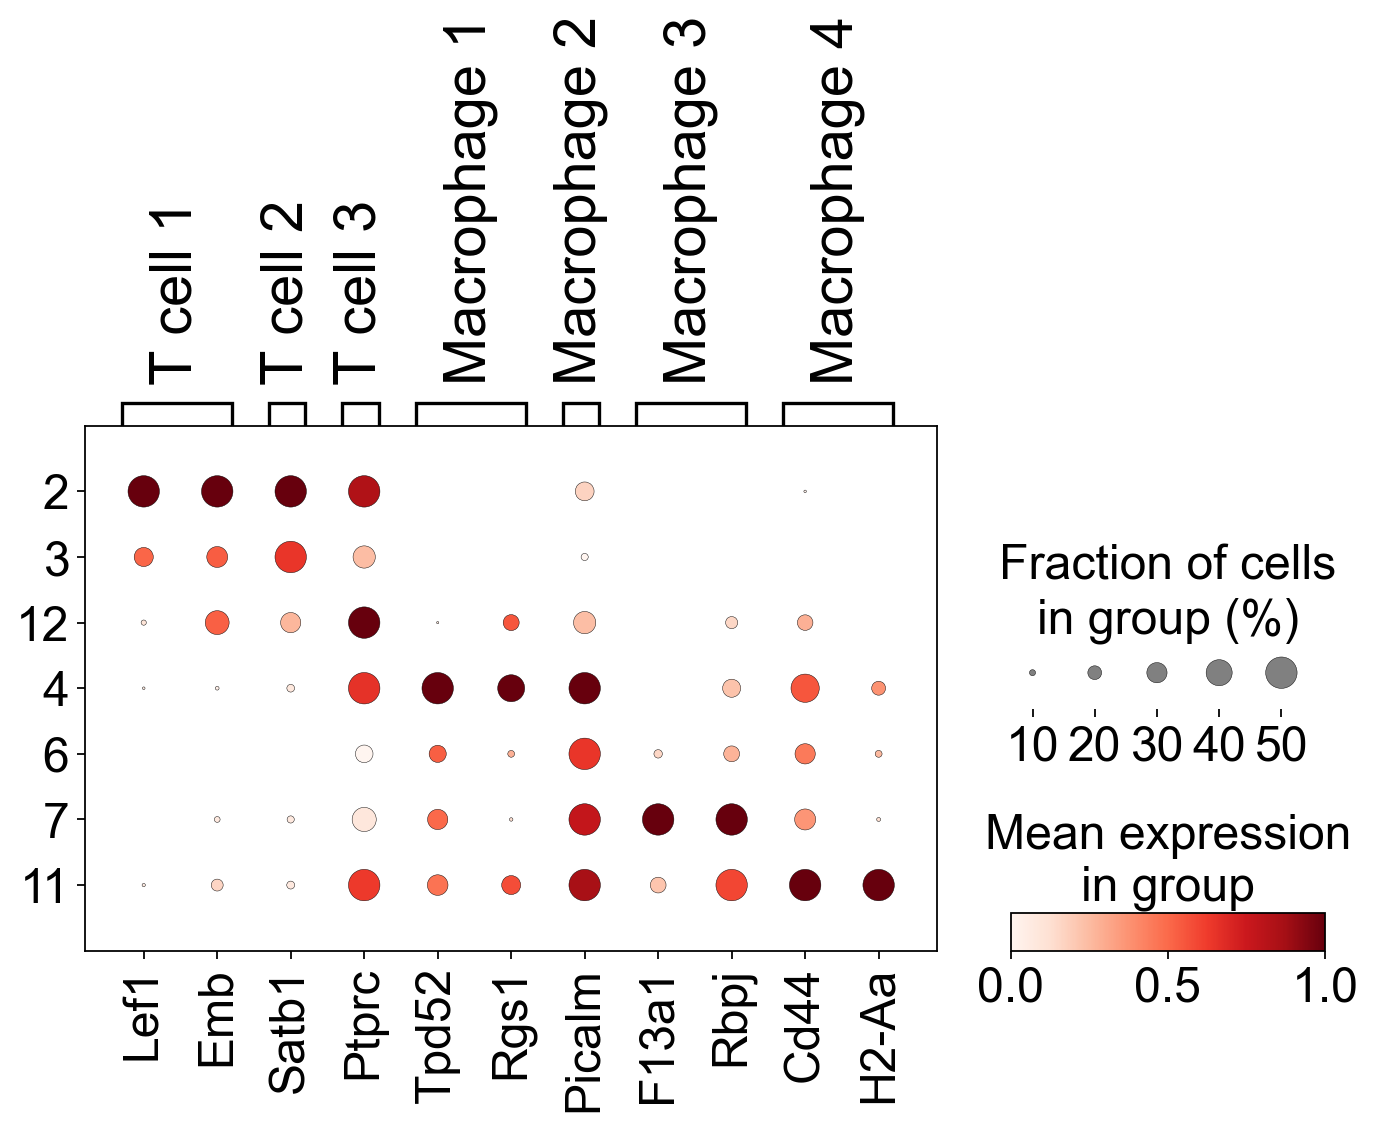

In [14]:
marker_genes = {"T cell 1": ["Lef1", "Emb"], 
                            "T cell 2": ["Satb1"], 
                            "T cell 3": ["Ptprc"], 
                            "Macrophage 1": ["Tpd52", "Rgs1"], 
                            "Macrophage 2": ["Picalm"],
                            "Macrophage 3": ["F13a1", "Rbpj"], 
                            "Macrophage 4": ["Cd44", "H2-Aa"]}
marker_genes_dict = dict()


for ct, markers in marker_genes.items():
    markers_found = list()
    
    for marker in markers:
        if marker in adata.var_names:
            markers_found.append(marker)
    marker_genes_dict[ct] = markers_found
    
del_markers = list()

for ct, markers in marker_genes_dict.items():
    if markers == []:
        del_markers.append(ct)
        
for ct in del_markers:
    del marker_genes_dict[ct]
    
    
order = ["2", "3", "12", "4", "6", "7", "11"]
adata1 = adata[adata.obs["labels"].isin(order), :].copy()
adata1.var_names_make_unique()
adata1.obs["labels"] = adata1.obs["labels"].astype("str")
adata1.obs["labels"] = adata1.obs["labels"].astype("category")
fig, ax = plt.subplots(figsize = (10, 6))
sc.pl.dotplot(adata1, groupby = "labels", var_names = marker_genes_dict, dot_max = 0.5, dot_min = 0.05, 
                     standard_scale = "var", categories_order = order, ax = ax, show = False)
plt.show()

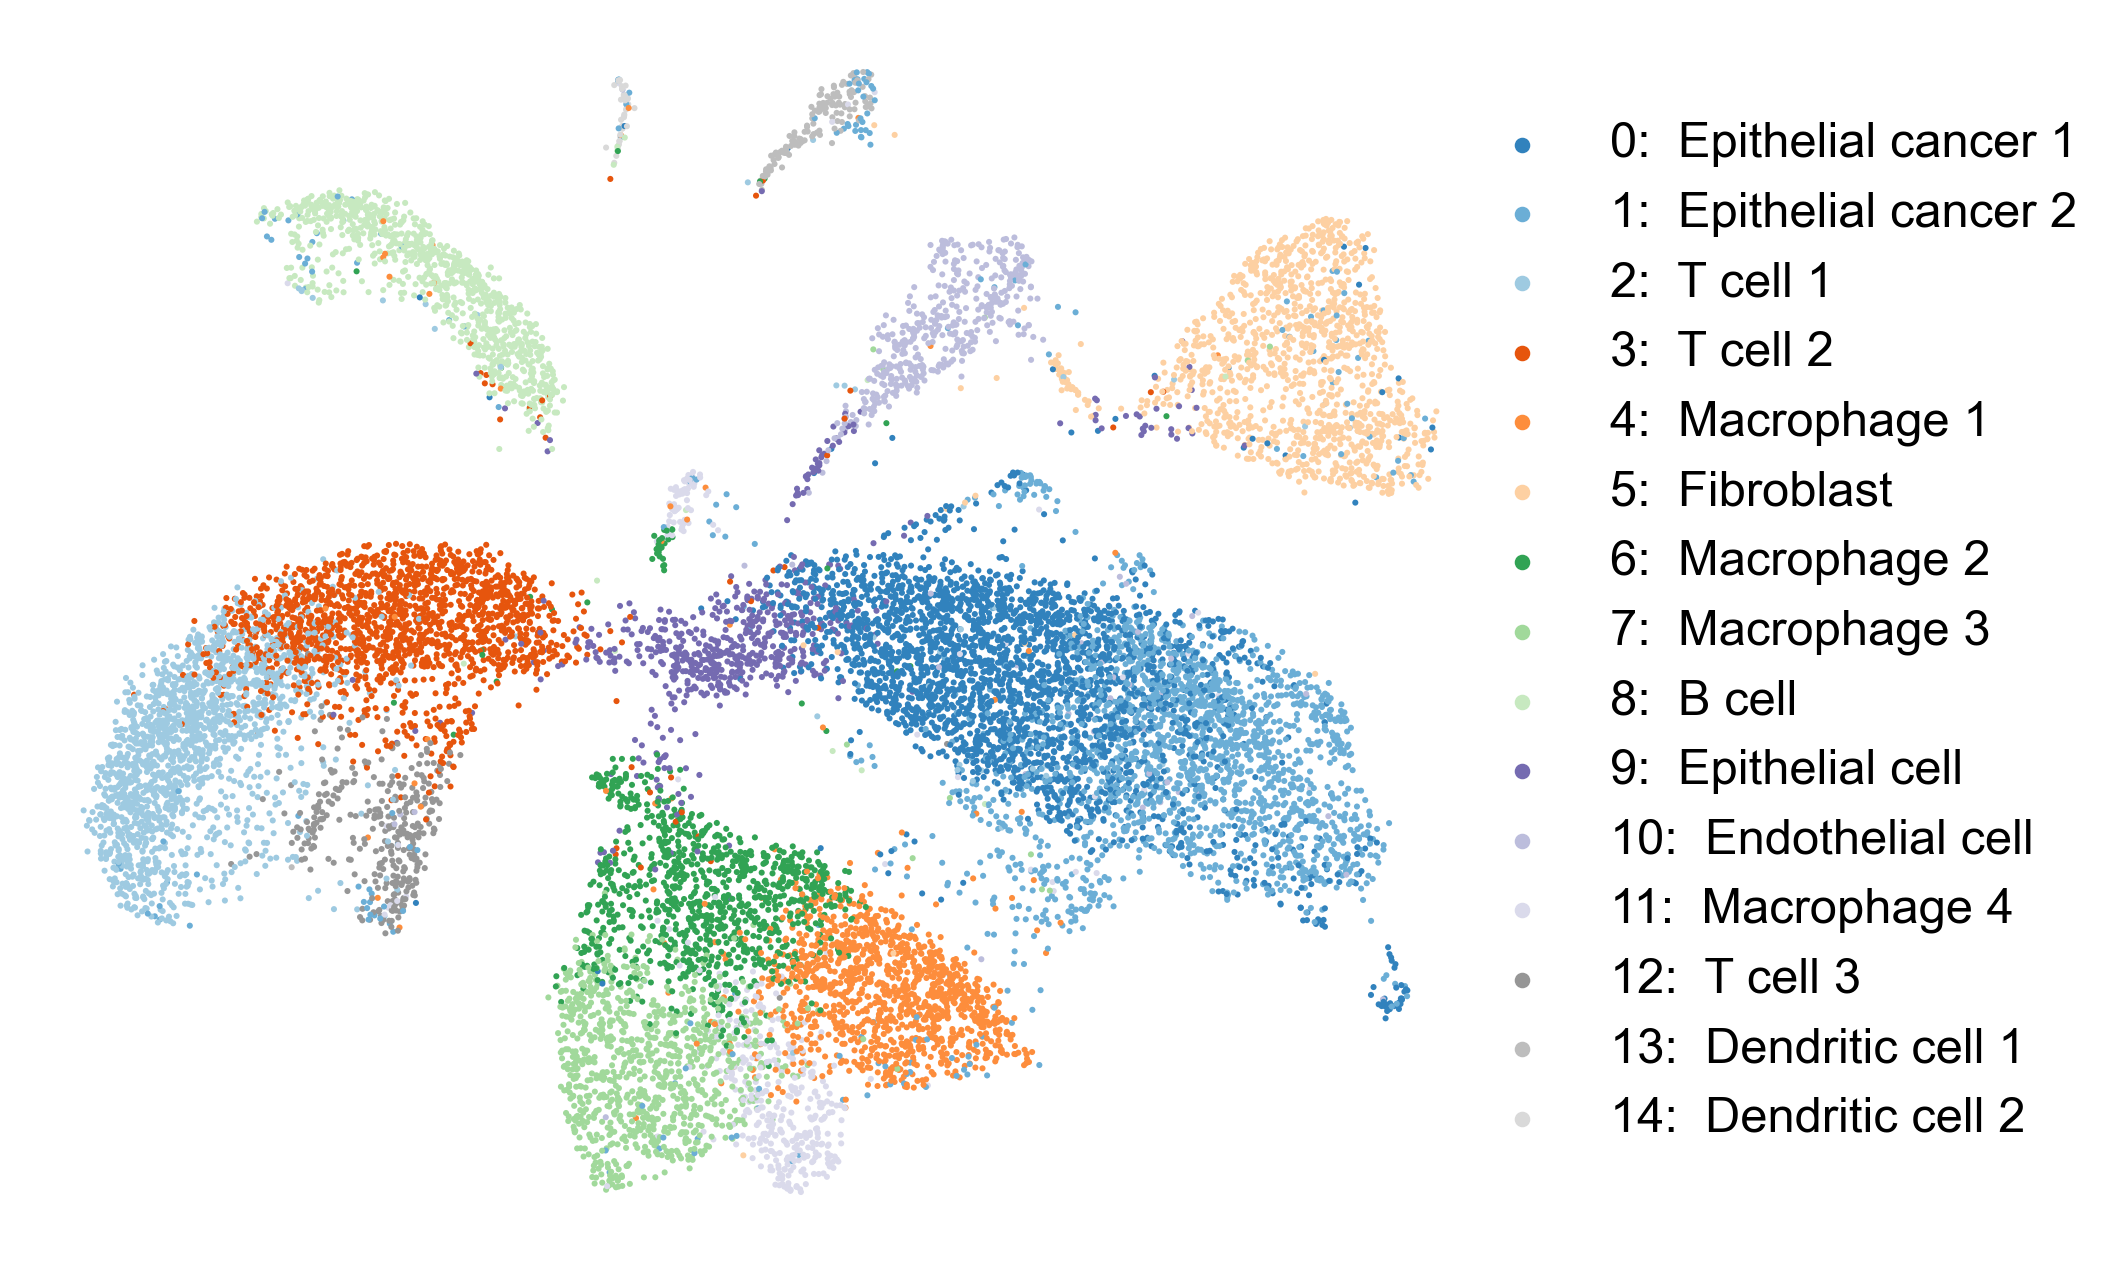

In [15]:
cell_type_dict = {"0": "0:  Epithelial cancer 1", "1": "1:  Epithelial cancer 2", "2": "2:  T cell 1", "3": "3:  T cell 2", "4": "4:  Macrophage 1", 
                           "5": "5:  Fibroblast", "6": "6:  Macrophage 2", "7": "7:  Macrophage 3", "8": "8:  B cell", "9": "9:  Epithelial cell", 
                           "10": "10:  Endothelial cell", "11": "11:  Macrophage 4", "12": "12:  T cell 3", "13": "13:  Dendritic cell 1", 
                           "14": "14:  Dendritic cell 2"}
adata.obs["cell_types"] = adata.obs["labels"].map(cell_type_dict)
adata.obs["cell_types"] = adata.obs["cell_types"].astype("category")


sc.pp.neighbors(adata)
sc.tl.umap(adata)
fig, ax = plt.subplots(figsize = (12, 10))
sc.pl.umap(adata, size = 30, color = ["cell_types"], palette = "tab20c", title = "", frameon = False, ax = ax, show = False)
handles, labels = ax.get_legend_handles_labels()
desired_order = ["0:  Epithelial cancer 1", "1:  Epithelial cancer 2", "2:  T cell 1", "3:  T cell 2", "4:  Macrophage 1", "5:  Fibroblast", 
                            "6:  Macrophage 2", "7:  Macrophage 3", "8:  B cell", "9:  Epithelial cell", "10:  Endothelial cell", "11:  Macrophage 4", 
                            "12:  T cell 3", "13:  Dendritic cell 1", "14:  Dendritic cell 2"]
ordered_handles = []
ordered_labels = []


for label in desired_order:
    if label in labels:
        idx = labels.index(label)
        ordered_handles.append(handles[idx])
        ordered_labels.append(labels[idx])

        
ax.get_legend().remove()
ax.legend(ordered_handles, ordered_labels, loc = "center left", bbox_to_anchor = (0.95, 0.5), ncol = 1, fontsize = 22, frameon = False)

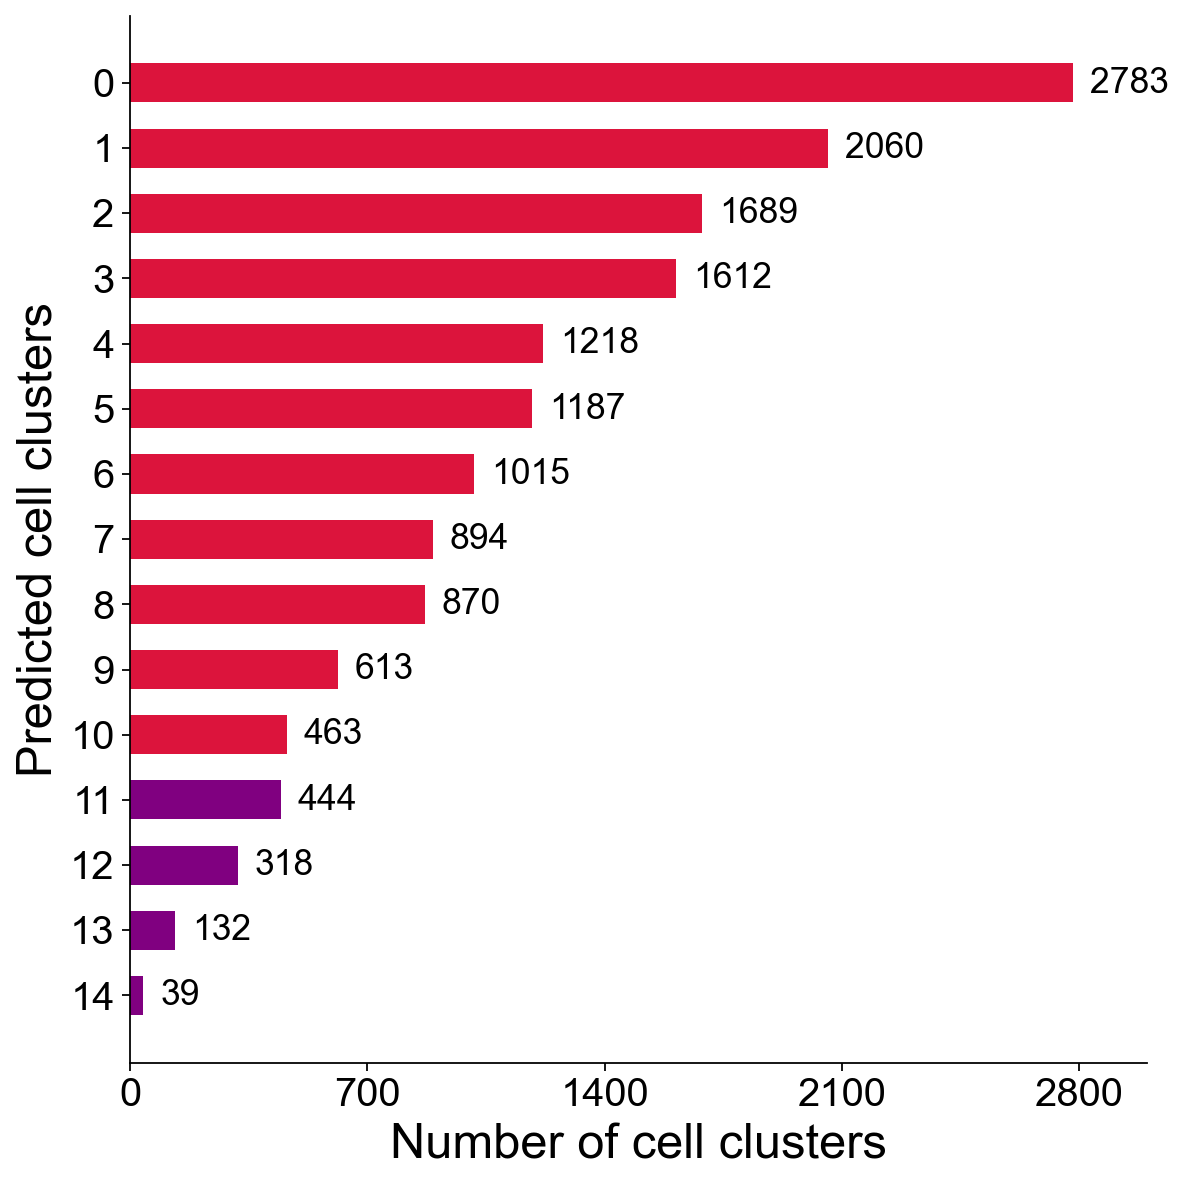

In [16]:
unique, counts = np.unique(pred_labels, return_counts = True)
percentages = counts / len(pred_labels) * 100
colors = ["#DC143C" if p > 3 else "#800080" for p in percentages]
fig, ax = plt.subplots(figsize = (8, 8))
bars = ax.barh(unique, counts, color = colors, edgecolor = "none", height = 0.6)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


for bar in bars:
    width = bar.get_width()
    ax.text(width + 50, bar.get_y() + bar.get_height() / 2, f"{int(width)}", ha = "left", va = "center", fontsize = 16)

    
ax.set_xlim(0, 3000)
plt.xticks([0, 700, 1400, 2100, 2800], fontsize = 18)
plt.yticks(list(range(15)), fontsize = 18)
ax.set_ylabel("Predicted cell clusters", fontsize = 22)
ax.set_xlabel("Number of cell clusters", fontsize = 22)
plt.tight_layout()
plt.show()

In [17]:
import gseapy as gp


sc.tl.rank_genes_groups(adata, groupby = "labels", method = "wilcoxon", use_raw = True)
clusters = adata.obs["labels"].cat.categories.tolist()
gene_sets = ["GO_Biological_Process_2023", "KEGG_2019_Mouse"]
organism = "Mouse"
 
    
for cluster in clusters:
    print(f"\nProcessing cluster {cluster}...")
    deg_df = pd.DataFrame({"names": adata.uns["rank_genes_groups"]["names"][cluster],
                                             "scores": adata.uns["rank_genes_groups"]["scores"][cluster],
                                             "pvals": adata.uns["rank_genes_groups"]["pvals"][cluster],
                                             "pvals_adj": adata.uns["rank_genes_groups"]["pvals_adj"][cluster],
                                             "logfoldchanges": adata.uns["rank_genes_groups"]["logfoldchanges"][cluster]})
    
    significant_genes = deg_df[(deg_df["pvals_adj"] < 0.05) & (abs(deg_df["logfoldchanges"]) > 0.25)]
    
    if len(significant_genes) < 5:
        print(f"Cluster {cluster} has too few significant genes ({len(significant_genes)}), skipping...")
        continue
    
    gene_list = significant_genes.sort_values("scores", ascending = False)["names"].head(100).tolist()

    try:
        enr_results = gp.enrichr(gene_list = gene_list, gene_sets = gene_sets, organism = organism, outdir = None, cutoff = 0.05)
        deg_filename = f"./ComicGTN_reproducibility/Data/Mouse_breast_tumor/Enrichment_results/Cluster_{cluster}_differential_genes.csv"
        significant_genes.to_csv(deg_filename, index = False)
        
        if enr_results is not None:
            enr_filename = f"./ComicGTN_reproducibility/Data/Mouse_breast_tumor/Enrichment_results/Cluster_{cluster}_enrichment.csv"
            enr_results.res2d.to_csv(enr_filename)
        else:
            print(f"No enrichment results for cluster {cluster}...")
            
    except Exception as e:
        print(f"Error processing cluster {cluster}: {str(e)}...")

        
all_enrichments = []


for cluster in clusters:
    try:
        filename = f"./ComicGTN_reproducibility/Data/Mouse_breast_tumor/Enrichment_results/Cluster_{cluster}_enrichment.csv"
        
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            df["Cluster"] = cluster
            all_enrichments.append(df)
            
    except:
        continue

if all_enrichments:
    combined_enrichment = pd.concat(all_enrichments)
    combined_enrichment.to_csv("./ComicGTN_reproducibility/Data/Mouse_breast_tumor/Enrichment_results/Combined_enrichment_results.csv", index = False)
else:
    print("No enrichment results to combine...")

/home/jsl/anaconda3/envs/python3.10/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/jsl/anaconda3/envs/python3.10/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

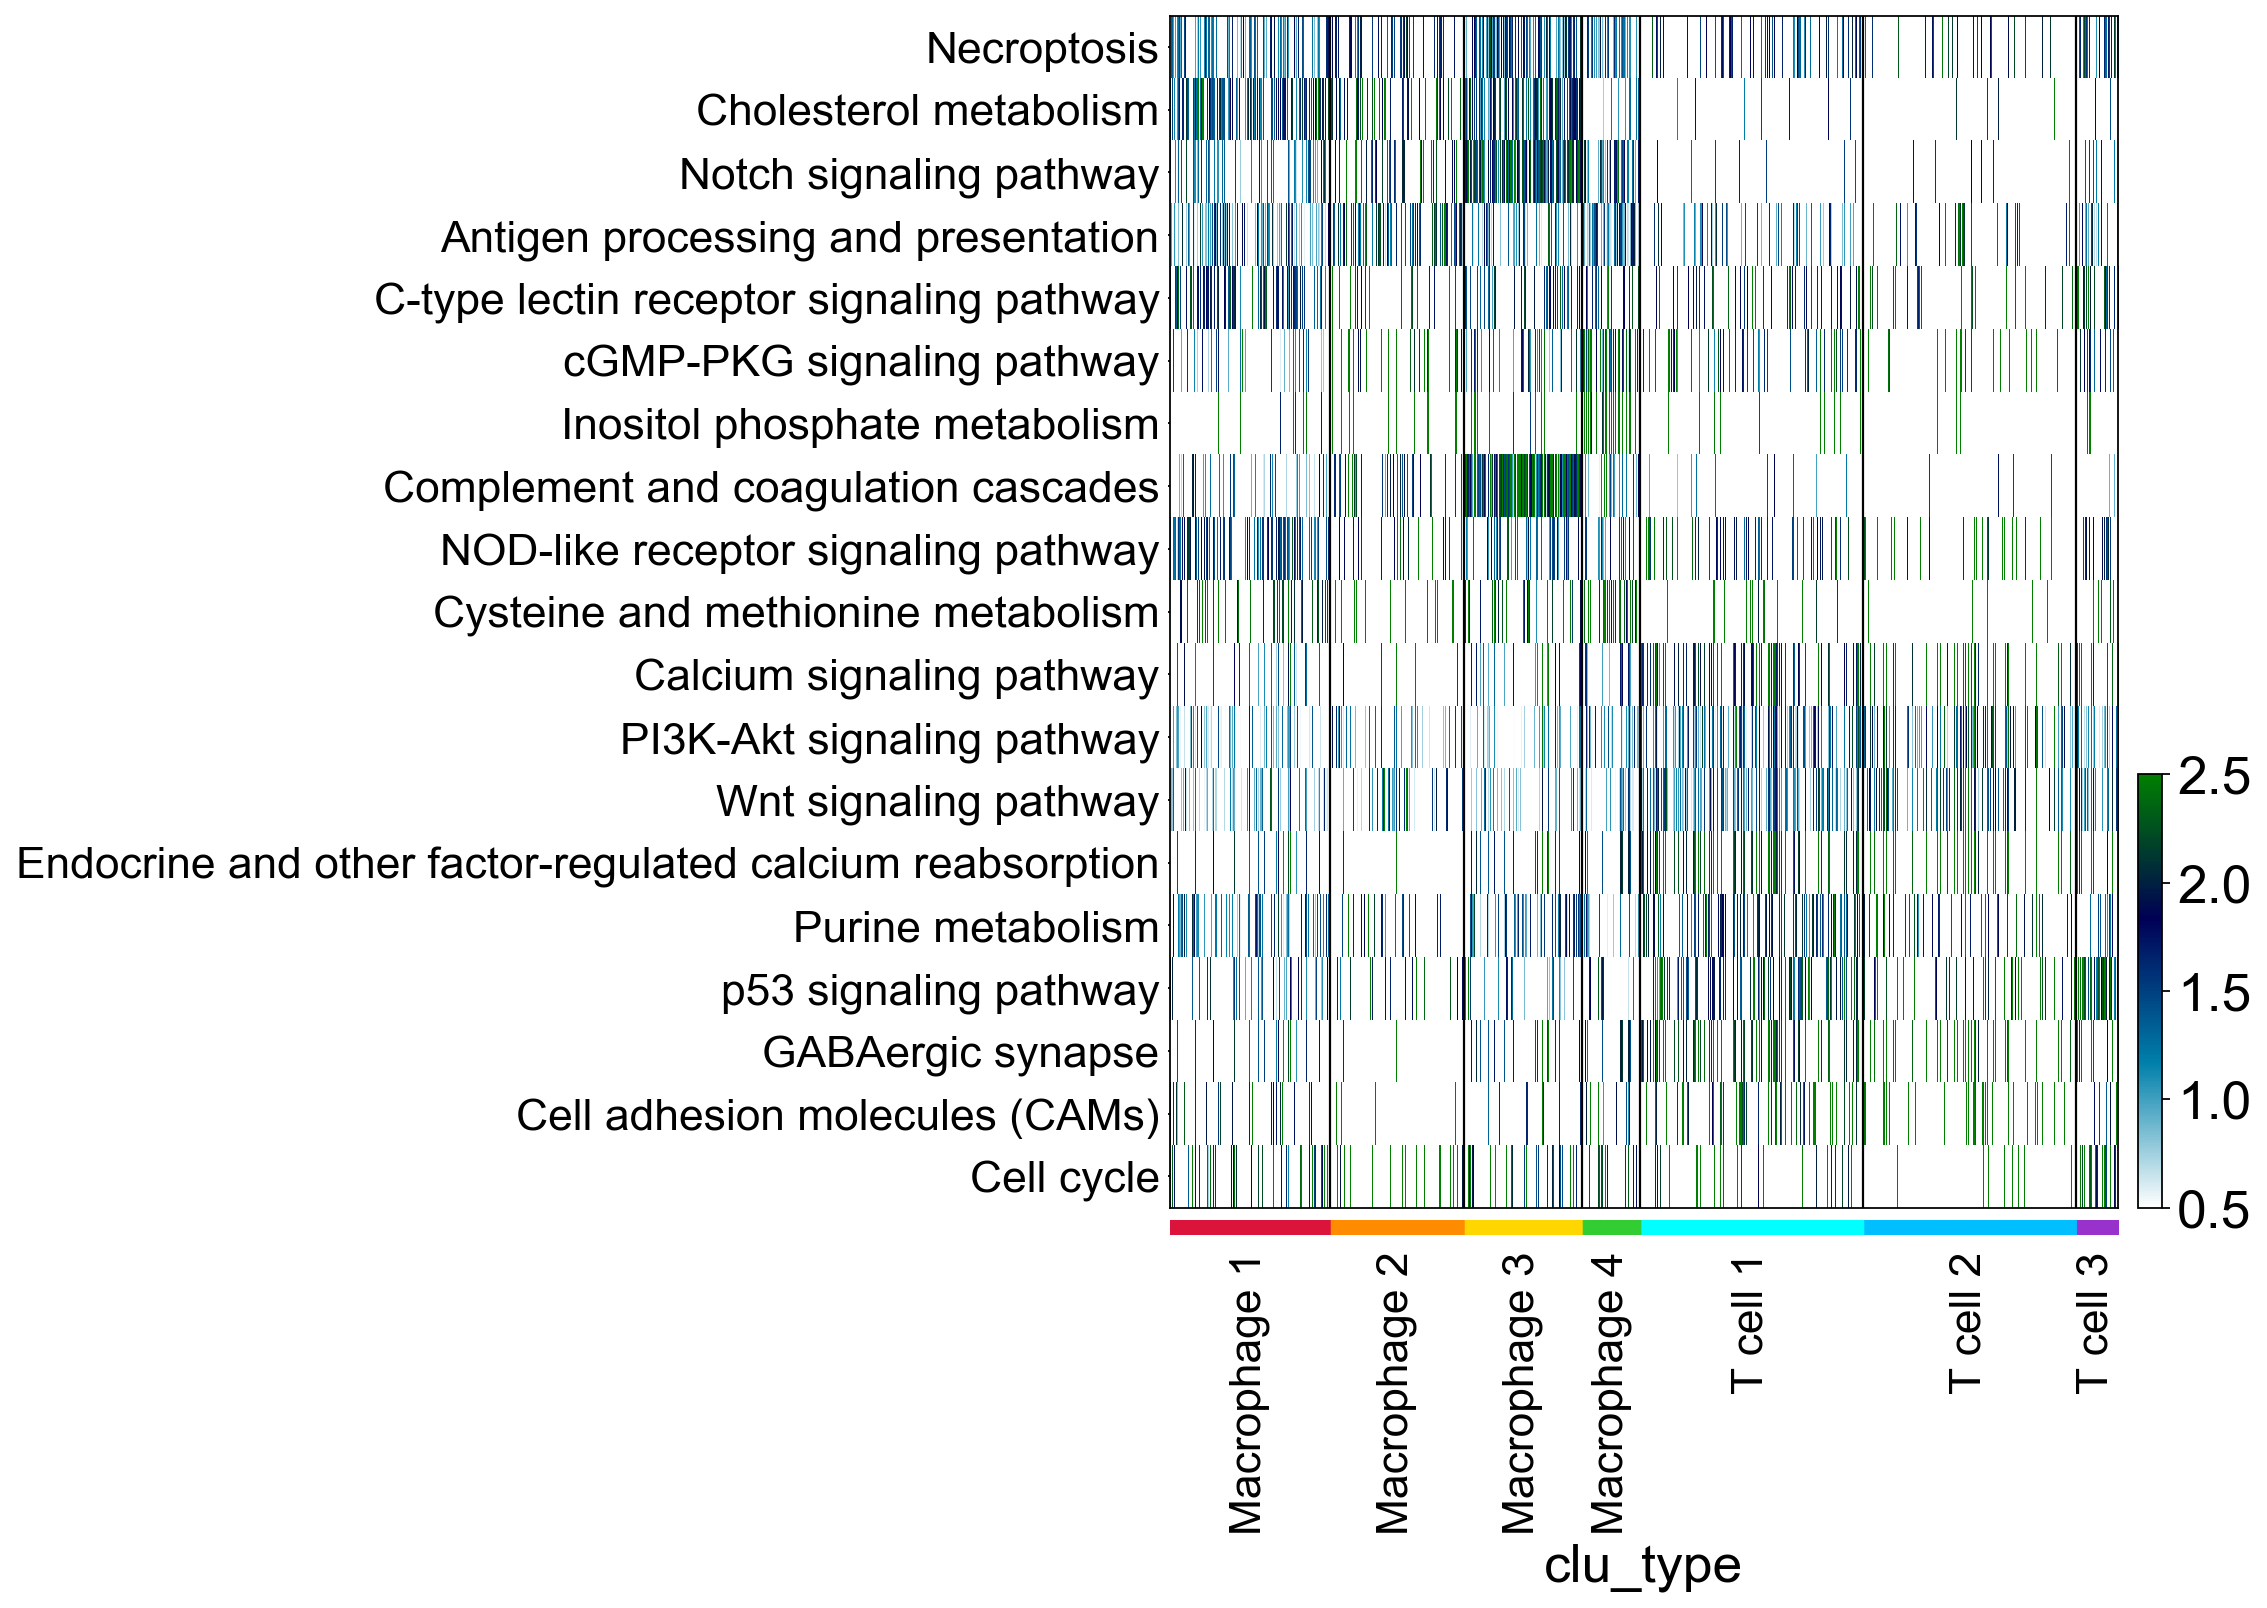

In [18]:
plt.rcParams["font.size"] = 24
ComicGTN_pred = pd.read_csv(os.path.join(workdir, "ComicGTN_pred.tsv"), sep = "\t", header = None)


combined_enrichment = pd.read_csv(os.path.join(workdir, "Enrichment_results/Combined_enrichment_results.csv"), header = 0)
combined_enrichment["Genes"] = combined_enrichment["Genes"].str.split(";").apply(lambda x: [item.strip() for item in x])
M1_list = list(combined_enrichment[combined_enrichment["Cluster"] == "4"]["Term"])
M2_list = list(combined_enrichment[combined_enrichment["Cluster"] == "6"]["Term"])
M3_list = list(combined_enrichment[combined_enrichment["Cluster"] == "7"]["Term"])
M4_list = list(combined_enrichment[combined_enrichment["Cluster"] == "11"]["Term"])
T1_list = list(combined_enrichment[combined_enrichment["Cluster"] == "2"]["Term"])
T2_list = list(combined_enrichment[combined_enrichment["Cluster"] == "3"]["Term"])
T3_list = list(combined_enrichment[combined_enrichment["Cluster"] == "12"]["Term"])


marker_dicts = {"M1": M1_list, "M2": M2_list, "M3": M3_list, "M4": M4_list, "T1": T1_list, "T2": T2_list, "T3": T3_list}
new_cluster_names = ["Epithelial cancer 1", "Epithelial cancer 2", "T cell 1", "T cell 2", "Macrophage 1", "Fibroblast", "Macrophage 2", 
                                    "Macrophage 3", "B cell", "Epithelial cell", "Endothelial cell", "Macrophage 4", "T cell 3", "Dendritic cell 1", 
                                    "Dendritic cell 2"]
clu_type = pd.Series(ComicGTN_pred[0]).astype(str)

for i in range(15):
    clu_type[clu_type == str(i)] = new_cluster_names[i]

Rare_list = [4, 6, 7, 11, 2, 3, 12]
Rare_index = np.zeros(len(ComicGTN_pred), dtype = "int64")

for r in Rare_list:
    Rare_index += np.array(ComicGTN_pred[0].tolist()) == r
Rare_index.sum()


adata1 = ad.AnnData(RNA_count.transpose(), dtype = "int32")[np.array(Rare_index, dtype = "bool")]
adata1.var_names = Gene_names[0].str.upper()
expression = np.zeros((7190, len(combined_enrichment)))

for index in range(len(combined_enrichment)):
    expression[:, index] = np.squeeze(np.array(adata1[:, np.array(combined_enrichment.iloc[index,10])].X.todense()).mean(axis = 1))
    
adata1 =  ad.AnnData(expression,dtype = "float32")
adata1.var_names = np.array(combined_enrichment.loc[:, "Term"])
adata1.var_names_make_unique()


sc.pp.normalize_total(adata1, target_sum = 1e4)
sc.pp.log1p(adata1)
sc.pp.scale(adata1, max_value = 10)
adata1.obs["clu_type"] = np.array(clu_type)[np.array(Rare_index, dtype = "bool")]
adata1.obs["clu_type"] = adata1.obs["clu_type"].astype("category")
adata1.uns["clu_type_colors"] = ["#DC143C", "#FF8C00", "#FFD700", "#32CD32", "#00FFFF", "#00BFFF", "#9932CC"]


marker_dicts = ["Necroptosis", "Cholesterol metabolism", "Notch signaling pathway", 
                          "Antigen processing and presentation",
                          "C-type lectin receptor signaling pathway", "cGMP-PKG signaling pathway", "Inositol phosphate metabolism",
                          "Complement and coagulation cascades", "NOD-like receptor signaling pathway", "Cysteine and methionine metabolism",
                          "Calcium signaling pathway", "PI3K-Akt signaling pathway", "Wnt signaling pathway", 
                          "Endocrine and other factor-regulated calcium reabsorption", "Purine metabolism", "p53 signaling pathway",
                          "GABAergic synapse", "Cell adhesion molecules (CAMs)", "Cell cycle"]


sc.pl.heatmap(adata1, marker_dicts, groupby = "clu_type", swap_axes = True, vcenter = 1.5, vmin = 0.5, vmax = 2.5, 
                       figsize = (8, 10), cmap = "ocean_r", show = False)
plt.show

2026-04-13 21:20:18,721 [WARNING] Duplicated values found in preranked stats: 0.10% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


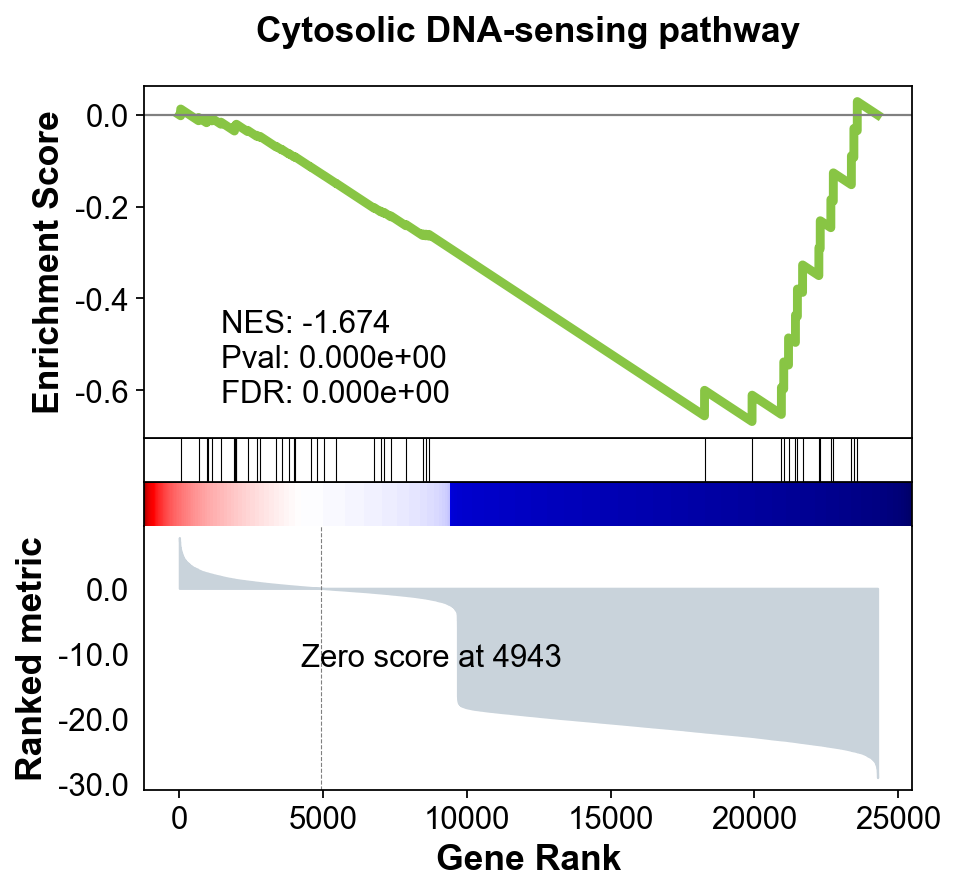

In [22]:
import gseapy as gp

sc.tl.rank_genes_groups(adata, groupby = "labels", method = "wilcoxon", use_raw = True)
clusters = adata.obs["labels"].cat.categories.tolist()
gene_sets = "KEGG_2019_Mouse"


Deg_df1 = pd.DataFrame({"names": adata.uns["rank_genes_groups"]["names"]["13"],
                                           "scores": adata.uns["rank_genes_groups"]["scores"]["13"],
                                           "pvals": adata.uns["rank_genes_groups"]["pvals"]["13"],
                                           "pvals_adj": adata.uns["rank_genes_groups"]["pvals_adj"]["13"],
                                           "logfoldchanges": adata.uns["rank_genes_groups"]["logfoldchanges"]["13"]})
Ranking1 = Deg_df1[["names", "logfoldchanges"]]
Ranking1 = Ranking1.sort_values("logfoldchanges", ascending = False).reset_index(drop = True)
pre_res1 = gp.prerank(rnk = Ranking1, gene_sets = gene_sets, seed = 6, permutation_num = 100)
out = []

for term in list(pre_res1.results):
    out.append([term, pre_res1.results[term]["fdr"], pre_res1.results[term]["es"], pre_res1.results[term]["nes"]])

out_df = pd.DataFrame(out, columns = ["Term", "fdr", "es", "nes"]).sort_values("fdr").reset_index(drop = True)
term_to_graph = "Cytosolic DNA-sensing pathway"
ax = gp.gseaplot(rank_metric = pre_res1.ranking, term = term_to_graph, **pre_res1.results[term_to_graph])

2026-04-13 21:21:17,973 [WARNING] Duplicated values found in preranked stats: 0.15% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


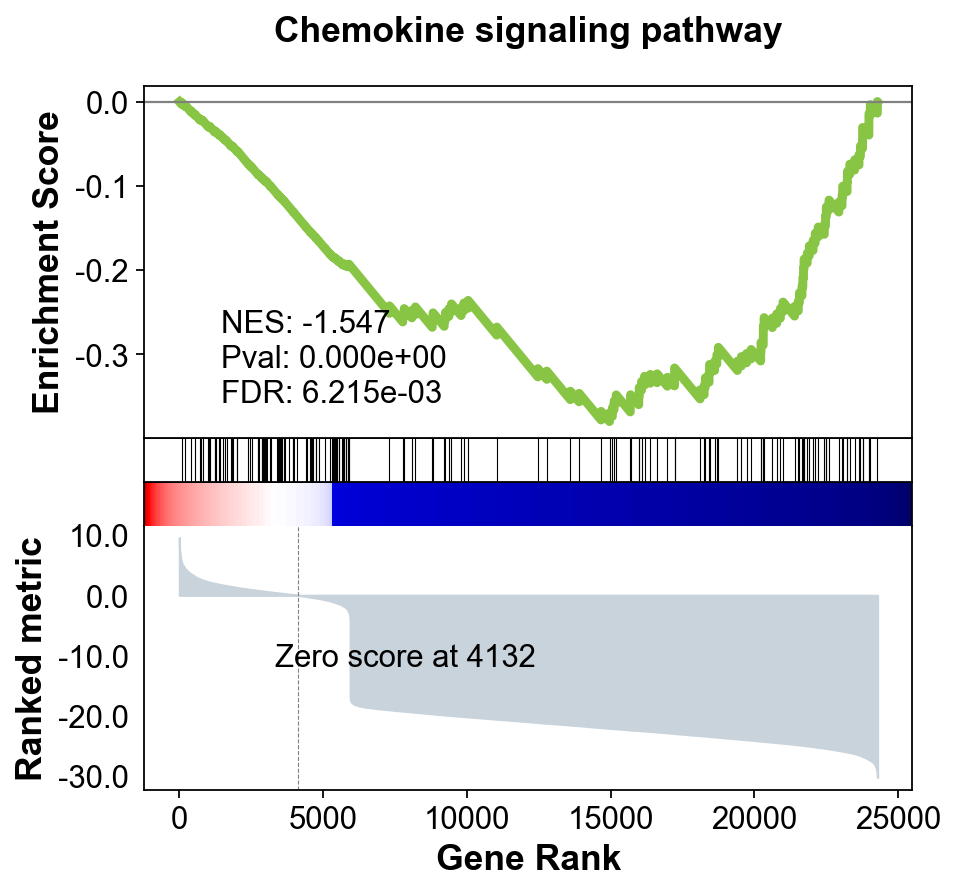

In [23]:
sc.tl.rank_genes_groups(adata, groupby = "labels", method = "wilcoxon", use_raw = True)
clusters = adata.obs["labels"].cat.categories.tolist()
gene_sets = "KEGG_2019_Mouse"


Deg_df2 = pd.DataFrame({"names": adata.uns["rank_genes_groups"]["names"]["14"],
                                           "scores": adata.uns["rank_genes_groups"]["scores"]["14"],
                                           "pvals": adata.uns["rank_genes_groups"]["pvals"]["14"],
                                           "pvals_adj": adata.uns["rank_genes_groups"]["pvals_adj"]["14"],
                                           "logfoldchanges": adata.uns["rank_genes_groups"]["logfoldchanges"]["14"]})
Ranking2 = Deg_df2[["names", "logfoldchanges"]]
Ranking2 = Ranking2.sort_values("logfoldchanges", ascending = False).reset_index(drop = True)
pre_res2 = gp.prerank(rnk = Ranking2, gene_sets = gene_sets, seed = 6, threads = 4, min_size = 5, max_size = 1000, permutation_num = 1000)
out = []

for term in list(pre_res2.results):
    out.append([term, pre_res2.results[term]["fdr"], pre_res2.results[term]["es"], pre_res2.results[term]["nes"]])

out_df = pd.DataFrame(out, columns = ["Term","fdr", "es", "nes"]).sort_values("fdr").reset_index(drop = True)
term_to_graph = "Chemokine signaling pathway"
ax = gp.gseaplot(rank_metric = pre_res2.ranking, term = term_to_graph, **pre_res2.results[term_to_graph])